In [1]:
!nvidia-smi

Mon Aug  3 17:23:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

In [5]:
os.listdir('/content/drive/MyDrive/Datasets')

['Teen_Mental_Health_Dataset.csv', 'dataset_piante_garcia_sanabria.zip']

In [6]:
!unzip -q '/content/drive/MyDrive/Datasets/dataset_piante_garcia_sanabria.zip' -d /content/dataset

In [8]:
os.listdir('/content/dataset/dataset_piante_garcia_sanabria')

['altro',
 'alcalifa',
 'palmera_canaria',
 'drago',
 'mejorana',
 'olivo',
 'palmera_cola_pescado_ramificada']

In [1]:
from fastai.vision.all import *

In [2]:
path = Path('/content/dataset/dataset_piante_garcia_sanabria')

In [12]:
path.ls()

[Path('/content/dataset/dataset_piante_garcia_sanabria/altro'), Path('/content/dataset/dataset_piante_garcia_sanabria/alcalifa'), Path('/content/dataset/dataset_piante_garcia_sanabria/palmera_canaria'), Path('/content/dataset/dataset_piante_garcia_sanabria/drago'), Path('/content/dataset/dataset_piante_garcia_sanabria/mejorana'), Path('/content/dataset/dataset_piante_garcia_sanabria/olivo'), Path('/content/dataset/dataset_piante_garcia_sanabria/palmera_cola_pescado_ramificada')]

In [13]:
(path/'altro').ls()

[Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_02.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_27.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_12.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_28.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_14.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_16.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_08.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_10.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_23.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_25.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_11.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_24.jpg'), Path('/content/dataset/dataset_piante_garcia_sanabria/altro/altro_22.jpg'), Path('/cont

In [3]:
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct = 0.2,
    seed = 42,
    item_tfms = Resize(224),
    batch_tfms = aug_transforms()
)

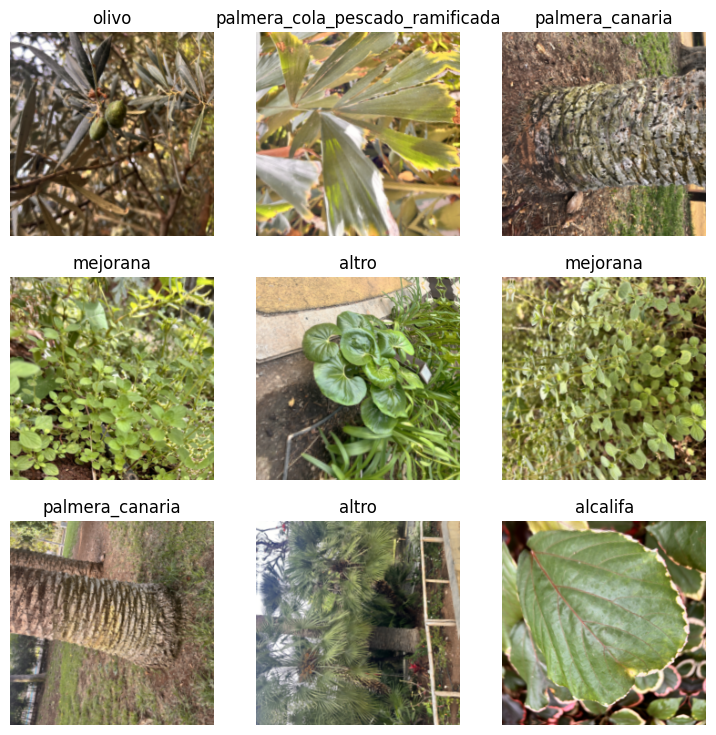

In [16]:
dls.show_batch(max_n = 9)

In [4]:
learn = vision_learner(dls, resnet34, metrics = error_rate)

In [23]:
!pip install -Uqq fastai fastcore

In [5]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,3.218192,3.169951,0.897436,00:44


epoch,train_loss,valid_loss,error_rate,time
0,2.928238,2.278818,0.717949,00:39
1,2.529082,1.334175,0.487179,00:38
2,2.028400,0.987559,0.384615,00:40


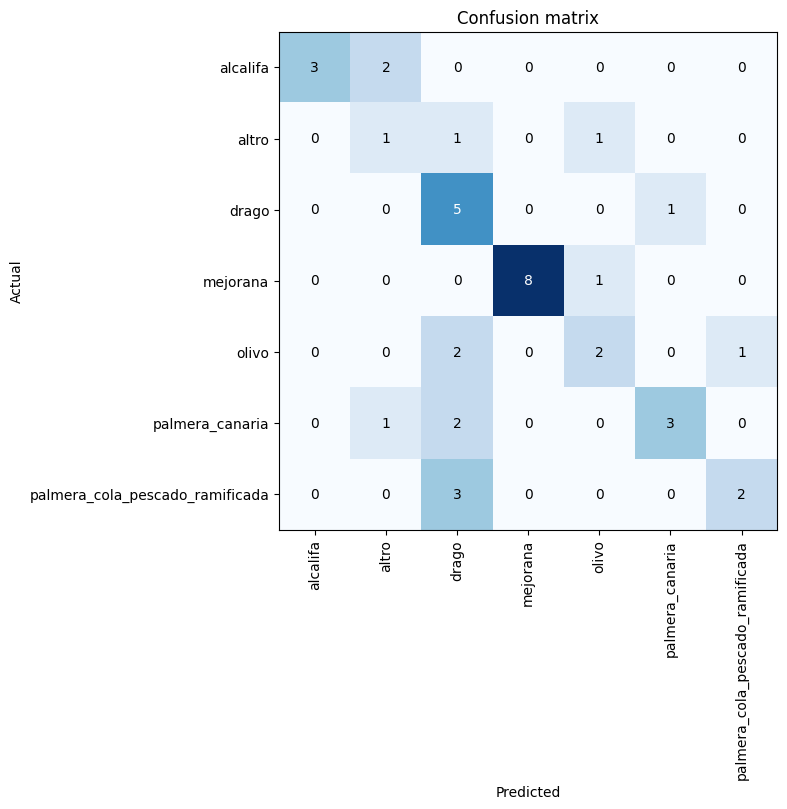

In [6]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize = (8,8))

In [9]:
interp.most_confused(min_val = 1)

[('palmera_cola_pescado_ramificada', 'drago', np.int64(3)),
 ('alcalifa', 'altro', np.int64(2)),
 ('olivo', 'drago', np.int64(2)),
 ('palmera_canaria', 'drago', np.int64(2)),
 ('altro', 'drago', np.int64(1)),
 ('altro', 'olivo', np.int64(1)),
 ('drago', 'palmera_canaria', np.int64(1)),
 ('mejorana', 'olivo', np.int64(1)),
 ('olivo', 'palmera_cola_pescado_ramificada', np.int64(1)),
 ('palmera_canaria', 'altro', np.int64(1))]

In [8]:
learn = vision_learner(dls, resnet34, metrics = error_rate)
learn.fine_tune(5)

epoch,train_loss,valid_loss,error_rate,time
0,3.209853,2.563388,0.743590,00:41


epoch,train_loss,valid_loss,error_rate,time
0,2.443053,1.845990,0.564103,00:40
1,2.253880,1.080126,0.307692,00:38
2,1.884297,0.765373,0.256410,00:42
3,1.573490,0.613323,0.179487,00:40
4,1.392782,0.535854,0.153846,00:40


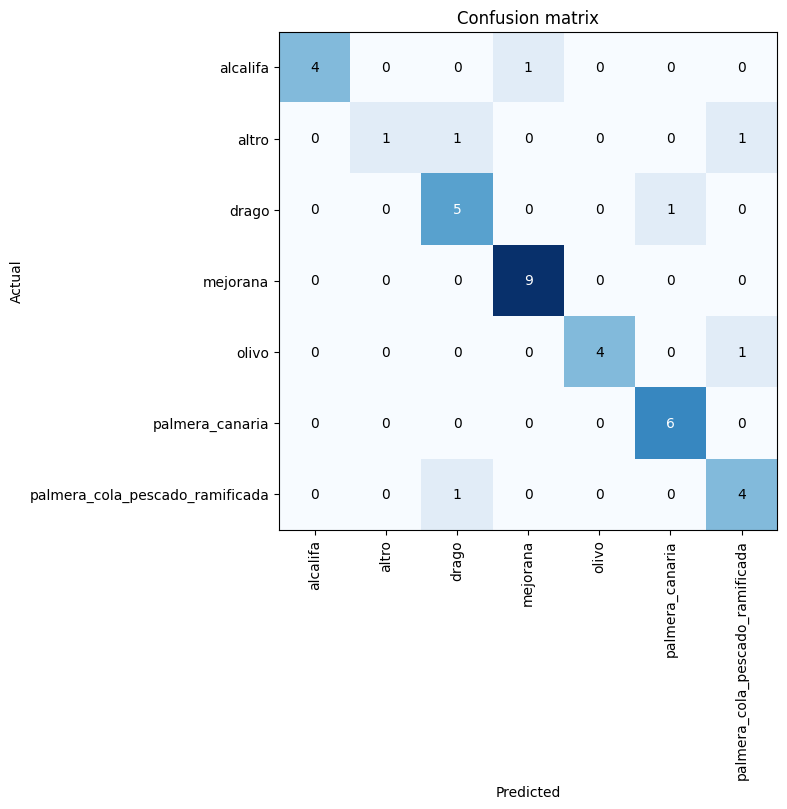

In [10]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize = (8,8))

In [11]:
interp.most_confused(min_val = 1)

[('alcalifa', 'mejorana', np.int64(1)),
 ('altro', 'drago', np.int64(1)),
 ('altro', 'palmera_cola_pescado_ramificada', np.int64(1)),
 ('drago', 'palmera_canaria', np.int64(1)),
 ('olivo', 'palmera_cola_pescado_ramificada', np.int64(1)),
 ('palmera_cola_pescado_ramificada', 'drago', np.int64(1))]

In [12]:
learn = vision_learner(dls, resnet34, metrics = error_rate)
learn.fine_tune(8)

epoch,train_loss,valid_loss,error_rate,time
0,3.027703,3.116327,0.794872,00:44


epoch,train_loss,valid_loss,error_rate,time
0,2.905390,2.266034,0.717949,00:43
1,2.467185,1.371639,0.538462,00:42
2,2.106162,0.680762,0.282051,00:41
3,1.808452,0.392345,0.128205,00:39
4,1.551241,0.303022,0.128205,00:41
5,1.329787,0.274056,0.102564,00:41
6,1.156598,0.256464,0.102564,00:41
7,1.031007,0.246219,0.076923,00:39


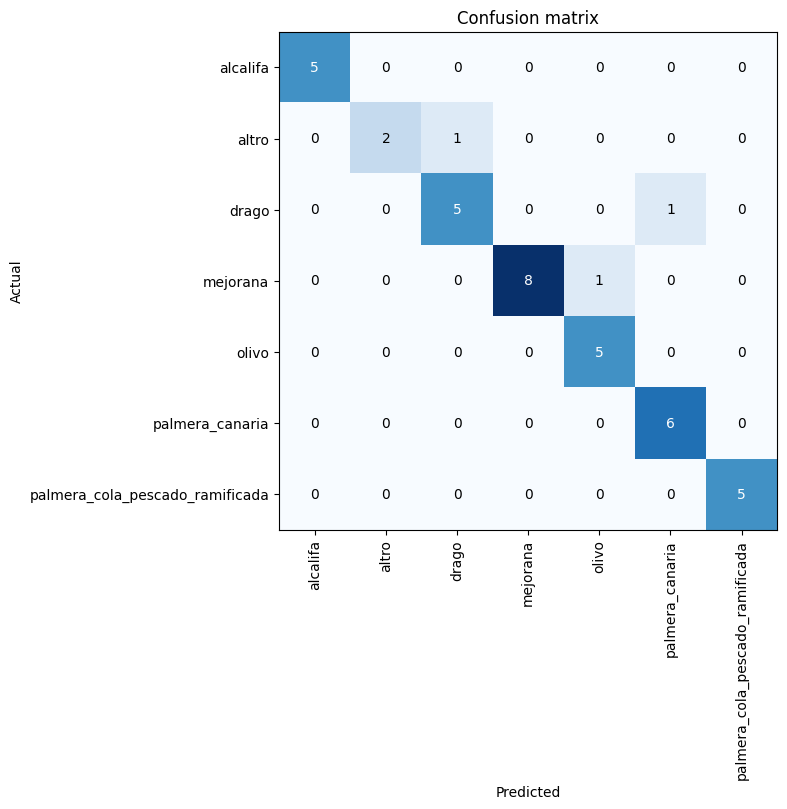

In [13]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize = (8,8))

In [14]:
interp.most_confused(min_val = 1)

[('altro', 'drago', np.int64(1)),
 ('drago', 'palmera_canaria', np.int64(1)),
 ('mejorana', 'olivo', np.int64(1))]

In [15]:
learn.export('modello_piante.pkl')

In [16]:
import os
os.listdir(path)

['modello_piante.pkl',
 'altro',
 'alcalifa',
 'palmera_canaria',
 'drago',
 'mejorana',
 'olivo',
 'palmera_cola_pescado_ramificada']

In [17]:
import shutil
shutil.copy(path/'modello_piante.pkl', '/content/drive/MyDrive/Datasets/modello_piante.pkl')

'/content/drive/MyDrive/Datasets/modello_piante.pkl'